# Exploratory Data Analysis
## Predicting Optimal Category-Store Inventory Levels at Walmart

**Goal:** Build demand forecasting models at the category-store level to determine inventory quantities that minimize operational costs — balancing the risk of overstocking (holding costs, spoilage) against understocking (lost sales, lost customers).

**Dataset:** Walmart M5 Forecasting Competition — 30,490 item-store combinations across 3 categories (FOODS, HOUSEHOLD, HOBBIES), 10 stores, 3 states (CA, TX, WI), spanning 1,913 days (Jan 2011 – Jun 2016).

**This notebook** explores the raw data to understand demand patterns, identify key drivers (discounts, SNAP issuance, calendar events), and assess data characteristics that will shape modeling decisions.

---

This notebook covers:
1. Data loading & structural overview
2. Aggregate daily sales & trends
3. Item-level sparsity analysis
4. Discount level identification
5. SNAP issuance effects & discount interaction
6. Calendar event effects

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Consistent plot style throughout the notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (14, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Load the Data

In [2]:
# ── Uncomment below when running on Google Colab ────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# os.chdir('/content/drive/MyDrive/Colab Notebooks/m5-forecasting-accuracy/notebooks')

In [3]:
# ── Load the three core M5 files ─────────────────────────────────────────────
DATA_DIR = "../data/raw/"

calendar    = pd.read_csv(DATA_DIR + "calendar.csv", parse_dates=["date"])
sell_prices = pd.read_csv(DATA_DIR + "sell_prices.csv")
sales       = pd.read_csv(DATA_DIR + "sales_train_validation.csv")

print(f"calendar    : {calendar.shape}")
print(f"sell_prices : {sell_prices.shape}")
print(f"sales       : {sales.shape}")

calendar    : (1969, 14)
sell_prices : (6841121, 4)
sales       : (30490, 1919)


---
## 2. Structural Overview

In [4]:
# ── Calendar overview ─────────────────────────────────────────────────────────
print("=== CALENDAR ===")
print(f"Date range : {calendar['date'].min().date()}  →  {calendar['date'].max().date()}")
print(f"Total days : {len(calendar)}\n")
print(calendar.head(3).to_string())
print(f"\nNull counts:\n{calendar.isnull().sum()[calendar.isnull().sum() > 0]}")

=== CALENDAR ===
Date range : 2011-01-29  →  2016-06-19
Total days : 1969

        date  wm_yr_wk   weekday  wday  month  year    d event_name_1 event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  snap_WI
0 2011-01-29     11101  Saturday     1      1  2011  d_1          NaN          NaN          NaN          NaN        0        0        0
1 2011-01-30     11101    Sunday     2      1  2011  d_2          NaN          NaN          NaN          NaN        0        0        0
2 2011-01-31     11101    Monday     3      1  2011  d_3          NaN          NaN          NaN          NaN        0        0        0

Null counts:
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
dtype: int64


In [5]:
# ── Sell prices overview ──────────────────────────────────────────────────────
print("=== SELL PRICES ===")
print(f"Unique stores : {sell_prices['store_id'].nunique()}")
print(f"Unique items  : {sell_prices['item_id'].nunique()}")
print(f"Week range    : {sell_prices['wm_yr_wk'].min()}  →  {sell_prices['wm_yr_wk'].max()}\n")
print(sell_prices.head(3).to_string())
print(f"\nPrice stats:\n{sell_prices['sell_price'].describe()}")

=== SELL PRICES ===
Unique stores : 10


Unique items  : 3049
Week range    : 11101  →  11621

  store_id        item_id  wm_yr_wk  sell_price
0     CA_1  HOBBIES_1_001     11325        9.58
1     CA_1  HOBBIES_1_001     11326        9.58
2     CA_1  HOBBIES_1_001     11327        8.26

Price stats:
count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64


In [6]:
# ── Sales overview ────────────────────────────────────────────────────────────
print("=== SALES ===")
print(f"Rows (items × store combinations) : {len(sales)}")
print(f"Columns (id cols + day cols)       : {sales.shape[1]}")

# Identify day columns (d_1, d_2, ...)
day_cols = [c for c in sales.columns if c.startswith("d_")]
print(f"Day columns : d_1  →  {day_cols[-1]}  ({len(day_cols)} days)\n")

# Category breakdown
print("Items per category:")
print(sales.groupby("cat_id")["item_id"].nunique().rename("unique_items"))
print()
print("Items per state:")
print(sales.groupby("state_id")["id"].count().rename("rows"))

=== SALES ===
Rows (items × store combinations) : 30490
Columns (id cols + day cols)       : 1919
Day columns : d_1  →  d_1913  (1913 days)

Items per category:
cat_id
FOODS        1437
HOBBIES       565
HOUSEHOLD    1047
Name: unique_items, dtype: int64

Items per state:
state_id
CA    12196
TX     9147
WI     9147
Name: rows, dtype: int64


---
## 3. Aggregate Daily Sales

We melt the wide-format sales table into a long format and join with the calendar to get actual dates.

In [7]:
# ── Compute total daily sales across all items & stores ───────────────────────
# Sum across all rows for each day column
daily_totals = sales[day_cols].sum(axis=0).reset_index()
daily_totals.columns = ["d", "total_sales"]

# Join with calendar to get real dates
daily_totals = daily_totals.merge(
    calendar[["d", "date", "event_name_1", "event_type_1",
              "event_name_2", "event_type_2",
              "snap_CA", "snap_TX", "snap_WI"]],
    on="d", how="left"
)

print(f"Daily sales table: {daily_totals.shape}")
daily_totals.head()

Daily sales table: (1913, 10)


,d,total_sales,date,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,d_1,32631,2011-01-29,NaN,NaN,NaN,NaN,0,0,0
1,d_2,31749,2011-01-30,NaN,NaN,NaN,NaN,0,0,0
2,d_3,23783,2011-01-31,NaN,NaN,NaN,NaN,0,0,0
3,d_4,25412,2011-02-01,NaN,NaN,NaN,NaN,1,1,0
4,d_5,19146,2011-02-02,NaN,NaN,NaN,NaN,1,0,1


---
## 4. Sales Trend Visualization

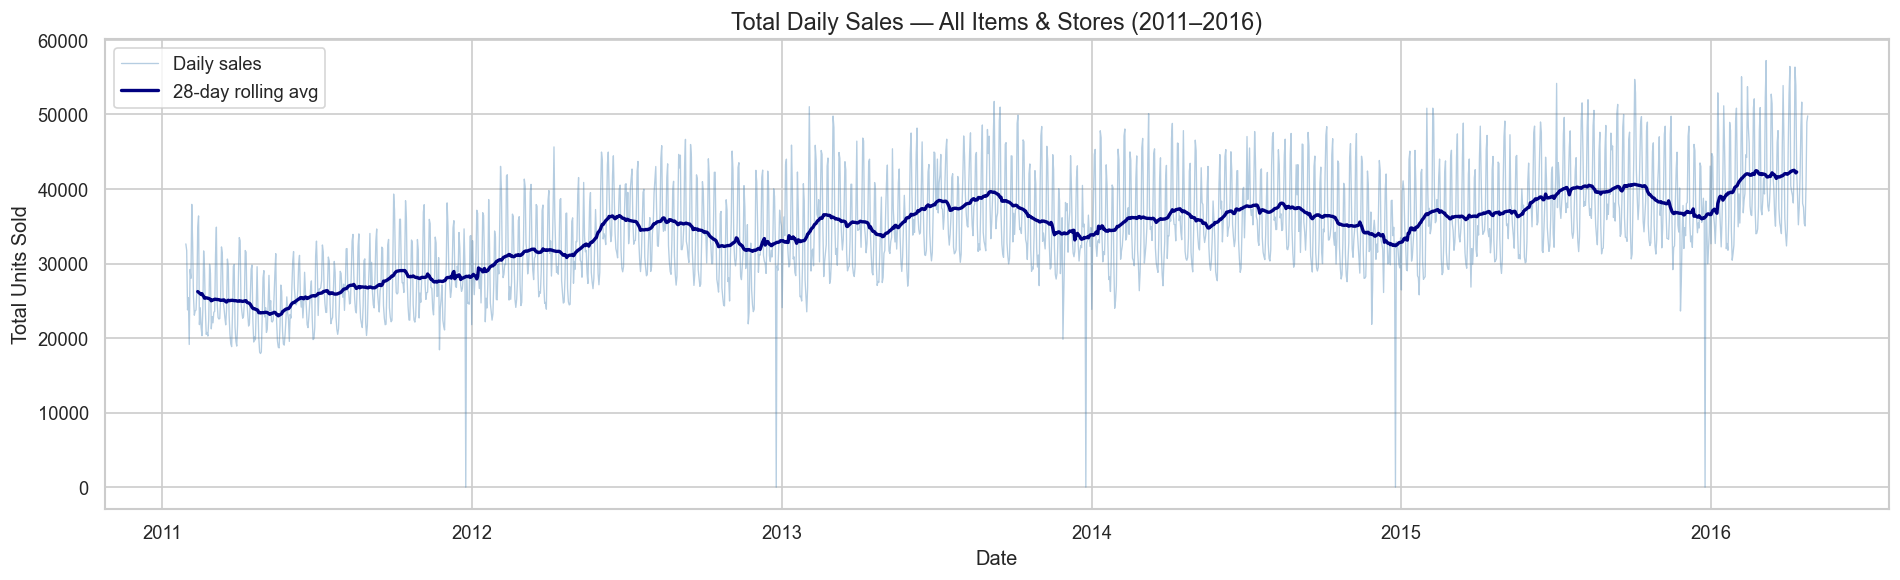

In [8]:
# ── Overall sales trend with 28-day rolling average ──────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(daily_totals["date"], daily_totals["total_sales"],
        color="steelblue", alpha=0.4, linewidth=0.8, label="Daily sales")
ax.plot(daily_totals["date"],
        daily_totals["total_sales"].rolling(28, center=True).mean(),
        color="navy", linewidth=2, label="28-day rolling avg")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Total Daily Sales — All Items & Stores (2011–2016)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Total Units Sold")
ax.legend()
plt.tight_layout()
plt.show()

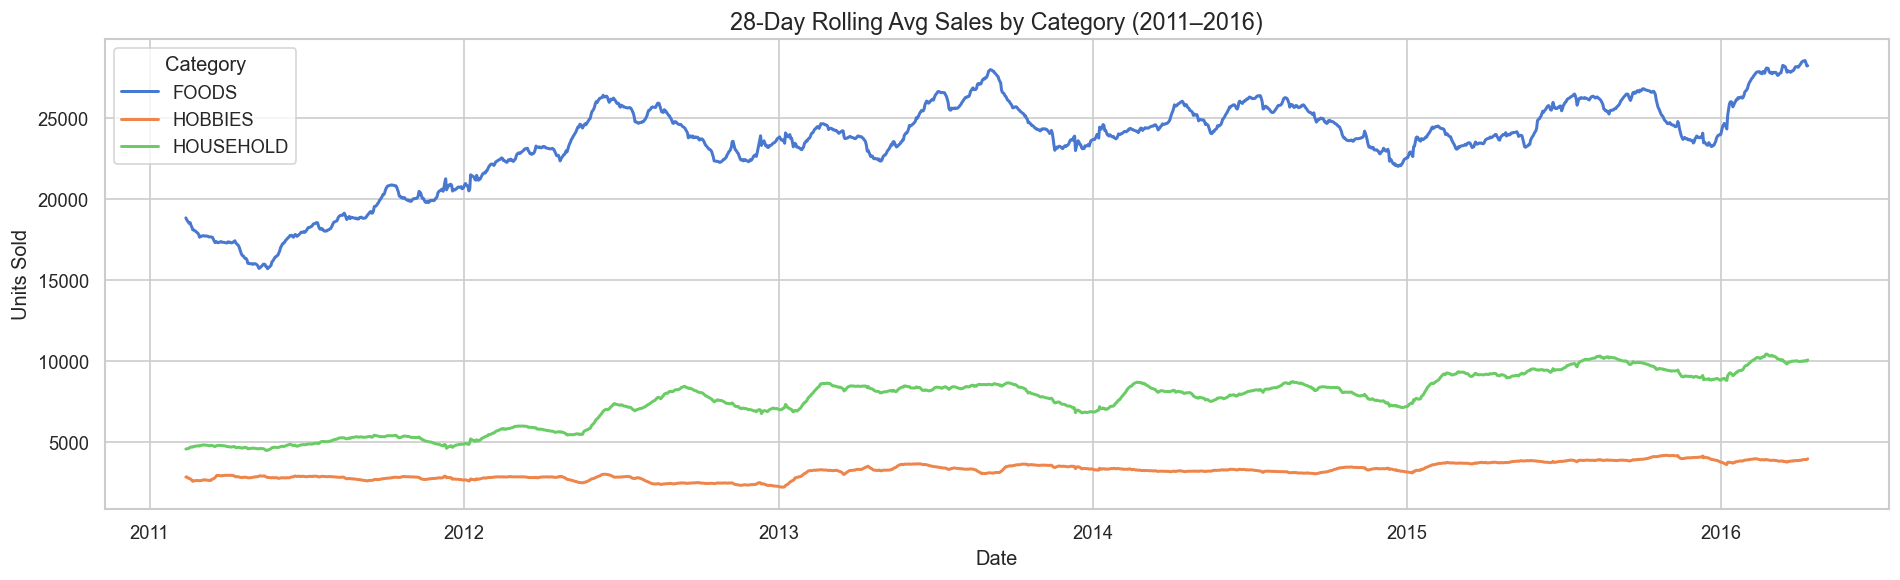

In [9]:
# ── Sales by category over time ───────────────────────────────────────────────
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

# Melt to long format (can take ~10 seconds on full dataset)
sales_long = sales.melt(id_vars=id_cols, value_vars=day_cols,
                        var_name="d", value_name="units")
sales_long = sales_long.merge(calendar[["d", "date"]], on="d", how="left")

# Daily sales by category
cat_daily = (sales_long
             .groupby(["date", "cat_id"])["units"]
             .sum()
             .reset_index())

fig, ax = plt.subplots(figsize=(16, 5))
for cat, grp in cat_daily.groupby("cat_id"):
    ax.plot(grp["date"], grp["units"].rolling(28, center=True).mean(),
            linewidth=1.8, label=cat)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("28-Day Rolling Avg Sales by Category (2011–2016)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")
ax.legend(title="Category")
plt.tight_layout()
plt.show()

In [10]:
# ── Item-level sparsity analysis ──────────────────────────────────────────────
zero_rate = (sales[day_cols] == 0).mean(axis=1)
print(f"Item-level zero-sales rate:")
print(f"  Mean:   {zero_rate.mean()*100:.1f}% of days have zero sales per item-store")
print(f"  Median: {zero_rate.median()*100:.1f}%")
print(f"  Items with >90% zeros: {(zero_rate > 0.9).sum():,} / {len(zero_rate):,} ({(zero_rate > 0.9).mean()*100:.1f}%)")

print(f"\nZero-rate by category:")
for cat in sorted(sales["cat_id"].unique()):
    cat_zeros = (sales.loc[sales["cat_id"] == cat, day_cols] == 0).mean(axis=1).mean()
    print(f"  {cat:12s}: {cat_zeros*100:.1f}%")

Item-level zero-sales rate:
  Mean:   68.2% of days have zero sales per item-store
  Median: 73.5%
  Items with >90% zeros: 5,284 / 30,490 (17.3%)

Zero-rate by category:
  FOODS       : 62.0%


  HOBBIES     : 77.3%
  HOUSEHOLD   : 71.8%


### Interpretation

At the item-store level, sales data is extremely sparse — the majority of item-store pairs record zero sales on most days. This high sparsity makes item-level forecasting unreliable, as models would be predicting zeros most of the time. Aggregating to the **category-store level** (30 groups) addresses this by pooling items within each category at each store, producing a smoother, more stable demand signal that models can learn from effectively.

---
## 5. Discount Level Identification

In this section, we identify discount levels using item-level pricing data. For each item-store combination, we define a reference price using the median selling price over time, then calculate the discount percentage as the reduction from that reference price.

We then group observations into discount categories such as no discount, low discount, medium discount, and high discount.
*   Low Discount: <5%
*   Medium Discount: 5-10%
*   High Discount: 10%+

This allows us to analyze how sales behave under different discount conditions and sets up the later inventory optimization problem.

In [11]:
# ── 5. Discount Level Identification ─────────────────────────────────────────

# Sort for consistency
sell_prices_sorted = sell_prices.sort_values(["store_id", "item_id", "wm_yr_wk"]).copy()

# Use each item-store's median price as the reference / regular price
sell_prices_sorted["regular_price"] = (
    sell_prices_sorted.groupby(["store_id", "item_id"])["sell_price"]
    .transform("median")
)

# Compute discount percentage relative to regular price
sell_prices_sorted["discount_pct"] = (
    (sell_prices_sorted["regular_price"] - sell_prices_sorted["sell_price"])
    / sell_prices_sorted["regular_price"]
)

# Prevent negative discounts if current price is above median
sell_prices_sorted["discount_pct"] = sell_prices_sorted["discount_pct"].clip(lower=0)

# Create discount level bins at the item-store-week level
sell_prices_sorted["discount_level"] = pd.cut(
    sell_prices_sorted["discount_pct"],
    bins=[-0.001, 0.01, 0.05, 0.10, 1.0],
    labels=["No Discount", "Low Discount", "Medium Discount", "High Discount"]
)

# Summary at item-store-week level
discount_counts = sell_prices_sorted["discount_level"].value_counts().sort_index()
discount_share = (
    sell_prices_sorted["discount_level"].value_counts(normalize=True).sort_index() * 100
)

print("Discount level breakdown (item-store-week level):")
for level in discount_counts.index:
    print(f"  {level:15s}: {discount_counts[level]:,} rows ({discount_share[level]:.1f}%)")

Discount level breakdown (item-store-week level):
  No Discount    : 5,969,335 rows (87.3%)
  Low Discount   : 286,475 rows (4.2%)
  Medium Discount: 315,777 rows (4.6%)
  High Discount  : 269,534 rows (3.9%)


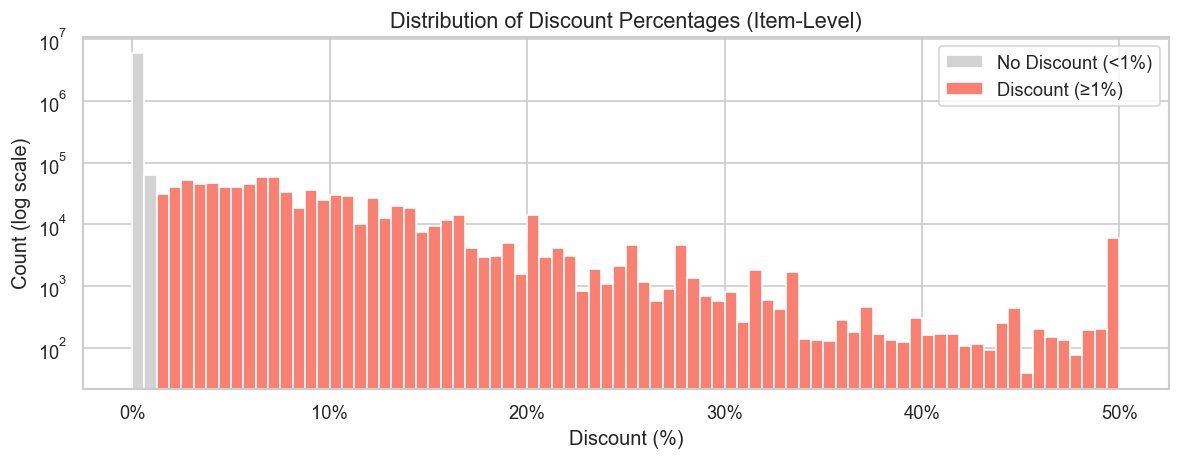

In [12]:
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 4))

# Data
data = sell_prices_sorted["discount_pct"].dropna().clip(0, 0.5)

# Histogram
counts, bins, patches = ax.hist(data, bins=80, edgecolor="white")

# Color styling
for i, patch in enumerate(patches):
    bin_center = (bins[i] + bins[i+1]) / 2

    if bin_center < 0.01:
        patch.set_facecolor("lightgray")   # No discount
    else:
        patch.set_facecolor("salmon")      # Discount

# Log scale
ax.set_yscale("log")

# Convert x-axis to percentage
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Labels
ax.set_title("Distribution of Discount Percentages (Item-Level)", fontsize=13)
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Count (log scale)")

# Legend
legend_elements = [
    Patch(facecolor='lightgray', label='No Discount (<1%)'),
    Patch(facecolor='salmon', label='Discount (≥1%)')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

The distribution of discount percentages is highly skewed, with most observations clustered near zero (no discount). To better visualize meaningful discount activity, the histogram uses a log-scaled y-axis, which makes the relatively small number of discounted observations more visible.

Additionally, the no-discount region is muted in gray, while discounted observations are highlighted in salmon. This emphasizes the contrast between baseline pricing behavior and actual discount events, allowing us to better understand the frequency and magnitude of price reductions.

In [13]:
# ── Convert weekly discount data to daily discount data ──────────────────────

# Keep only needed columns
weekly_discount = sell_prices_sorted[["wm_yr_wk", "discount_pct"]].copy()

# Expand week-level discounts to daily dates using calendar
calendar_discount = calendar[["date", "wm_yr_wk"]].merge(
    weekly_discount,
    on="wm_yr_wk",
    how="left"
)

# Define a discounted observation
calendar_discount["is_discounted"] = calendar_discount["discount_pct"] > 0.01

# Daily discount summary
daily_discount = (
    calendar_discount.groupby("date")
    .agg(
        avg_discount_all=("discount_pct", "mean"),
        avg_discount_discounted=("discount_pct", lambda x: x[x > 0.01].mean()),
        max_discount=("discount_pct", "max"),
        discount_coverage=("is_discounted", "mean")
    )
    .reset_index()
)

# Fill missing values for days with no discounted items
daily_discount["avg_discount_discounted"] = daily_discount["avg_discount_discounted"].fillna(0)
daily_discount["max_discount"] = daily_discount["max_discount"].fillna(0)
daily_discount["discount_coverage"] = daily_discount["discount_coverage"].fillna(0)

# Use the 90th percentile of discount_pct to represent daily discount intensity.
# This captures the level of discounts among the more heavily discounted items
# without being overly influenced by extreme outliers (like max) or dilution (like mean).
daily_discount["discount_pct"] = calendar_discount.groupby("date")["discount_pct"].quantile(0.9).values

# Create daily discount level bins
daily_discount["discount_level"] = pd.cut(
    daily_discount["discount_pct"],
    bins=[-0.001, 0.01, 0.05, 0.10, 1.0],
    labels=["No Discount", "Low Discount", "Medium Discount", "High Discount"]
)

# Clean old columns if they already exist
daily_totals = daily_totals.drop(
    columns=[c for c in ["discount_pct", "discount_level", "discount_coverage", "max_discount"] if c in daily_totals.columns],
    errors="ignore"
)

# Merge daily discount info into daily_totals
daily_totals = daily_totals.merge(
    daily_discount[["date", "discount_pct", "discount_level", "discount_coverage", "max_discount"]],
    on="date",
    how="left"
)

print(daily_totals["discount_level"].value_counts(dropna=False))

print("\nDaily discount data merged into daily_totals.")
daily_totals[["date", "total_sales", "discount_pct", "discount_level", "discount_coverage", "max_discount"]].head(10)

discount_level
No Discount        1029
Medium Discount     399
High Discount       252
Low Discount        233
Name: count, dtype: int64

Daily discount data merged into daily_totals.


,date,total_sales,discount_pct,discount_level,discount_coverage,max_discount
0,2011-01-29,32631,0.140496,High Discount,0.435693,0.626866
1,2011-01-30,31749,0.140496,High Discount,0.435693,0.626866
2,2011-01-31,23783,0.140496,High Discount,0.435693,0.626866
3,2011-02-01,25412,0.140496,High Discount,0.435693,0.626866
4,2011-02-02,19146,0.140496,High Discount,0.435693,0.626866
5,2011-02-03,29211,0.140496,High Discount,0.435693,0.626866
6,2011-02-04,28010,0.140496,High Discount,0.435693,0.626866
7,2011-02-05,37932,0.137615,High Discount,0.426138,0.626866
8,2011-02-06,32736,0.137615,High Discount,0.426138,0.626866
9,2011-02-07,25572,0.137615,High Discount,0.426138,0.626866


To measure daily discount intensity, we use the 90th percentile of item-level discount percentages for each day. This approach captures the level of discounts among the more heavily discounted items, avoiding the dilution effect of averaging across all products and the instability of using extreme values such as the maximum.

This provides a more balanced and representative measure of discount activity, allowing us to meaningfully categorize days into no, low, medium, and high discount levels.

**Note:** Because sell prices are reported at weekly granularity (`wm_yr_wk`), all days within the same week share identical discount values. The discount level assigned to a given day reflects the pricing for that entire week, not intra-week variation. In feature engineering, this metric will be computed at the **category-store level** rather than aggregated across all products.

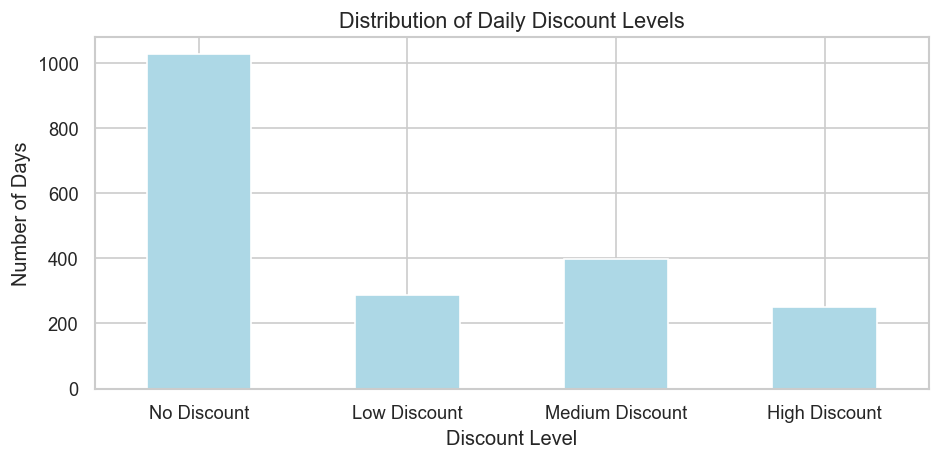

In [14]:
# ── Distribution of daily discount levels ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

daily_discount["discount_level"].value_counts().sort_index().plot(
    kind="bar",
    color="lightblue",
    ax=ax
)

ax.set_title("Distribution of Daily Discount Levels", fontsize=13)
ax.set_xlabel("Discount Level")
ax.set_ylabel("Number of Days")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

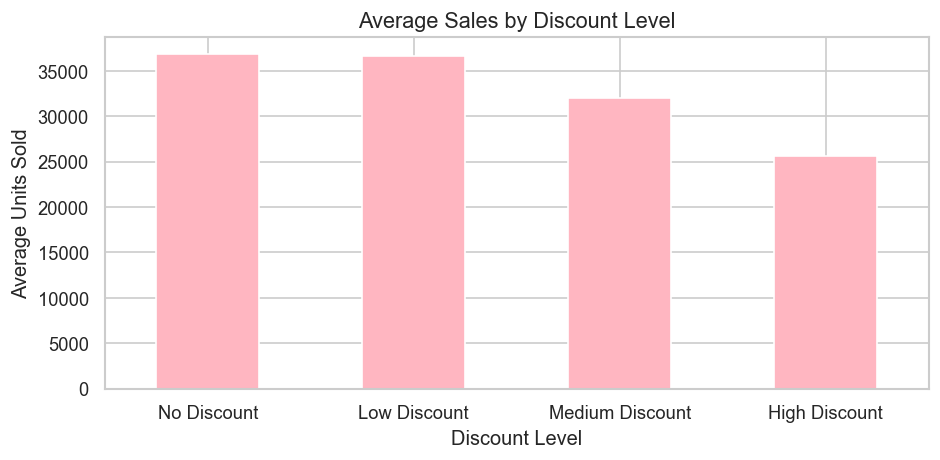

In [15]:
# ── Average sales by discount level ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

daily_totals.groupby("discount_level")["total_sales"].mean().plot(
    kind="bar",
    color="lightpink",
    ax=ax
)

ax.set_title("Average Sales by Discount Level", fontsize=13)
ax.set_xlabel("Discount Level")
ax.set_ylabel("Average Units Sold")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

Higher discount levels are associated with lower average sales at the aggregate level. However, this is a **correlation across different time periods**, not a causal estimate of discount impact. Days classified as "High Discount" also differ in seasonality, day-of-week mix, and event timing — these confounders are not controlled for here. The pattern likely reflects that deep discounts tend to occur during periods of generally lower demand (e.g., post-holiday clearance), rather than discounts themselves suppressing sales.

---
## 6. SNAP Issuance Effects and Discount Interaction

SNAP (Supplemental Nutrition Assistance Program) issuance days are when eligible customers receive food benefits. The M5 dataset includes per-state SNAP flags (CA, TX, WI), and these days are known to cause sales spikes — especially in food-related categories.

We first examine SNAP lift by state, then analyze how SNAP timing interacts with discount levels.

In [16]:
# ── SNAP sales lift per state ─────────────────────────────────────────────────
# Compute daily sales per state
state_daily = (
    sales_long.groupby(["date", "state_id"])["units"]
    .sum()
    .reset_index()
)
state_daily = state_daily.merge(
    calendar[["date", "snap_CA", "snap_TX", "snap_WI"]], on="date", how="left"
)

# Map state to its SNAP column
snap_map = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}

results = []
for state, snap_col in snap_map.items():
    sub = state_daily[state_daily["state_id"] == state]
    snap_avg   = sub[sub[snap_col] == 1]["units"].mean()
    normal_avg = sub[sub[snap_col] == 0]["units"].mean()
    results.append({
        "State": state,
        "SNAP days avg": round(snap_avg),
        "Normal days avg": round(normal_avg),
        "Lift %": round((snap_avg / normal_avg - 1) * 100, 1)
    })

snap_lift_df = pd.DataFrame(results)
print("Sales lift on SNAP days vs. non-SNAP days (per state):\n")
print(snap_lift_df.to_string(index=False))

Sales lift on SNAP days vs. non-SNAP days (per state):

State  SNAP days avg  Normal days avg  Lift %
   CA          15772            14606     8.0
   TX          10613             9519    11.5
   WI          10764             8839    21.8


### Interpretation

SNAP issuance days produce a consistent sales lift across all three states: **CA +8.0%**, **TX +11.5%**, **WI +21.8%**. The lift is strongest in Wisconsin, likely because WI has a higher proportion of SNAP-eligible households relative to total store traffic.

The varying magnitudes across states — despite all three sharing the same general issuance window (first half of each month) — suggest this is not purely a monthly pay-cycle effect. If it were, the lift would be similar across states. The fact that WI shows nearly 3× the lift of CA points to SNAP participation rates as a genuine demand driver.

### SNAP × Discount Interaction

We now examine how SNAP timing and discount levels interact at the **state level** — using each state's own SNAP flag rather than an aggregate flag, so the SNAP signal reflects actual issuance in that state.

In [17]:
# ── SNAP × Discount interaction (per state) ──────────────────────────────────

# Merge discount info into state_daily
state_daily_disc = state_daily.merge(
    daily_discount[["date", "discount_pct", "discount_level"]],
    on="date", how="left"
)

snap_map = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}

for state, snap_col in snap_map.items():
    sub = state_daily_disc[state_daily_disc["state_id"] == state].copy()
    sub["is_snap"] = sub[snap_col] == 1

    print(f"\n{state} — SNAP sales lift within each discount level:\n")
    for level in ["No Discount", "Low Discount", "Medium Discount", "High Discount"]:
        level_sub = sub[sub["discount_level"] == level]
        avg_non_snap = level_sub.loc[level_sub["is_snap"] == False, "units"].mean()
        avg_snap = level_sub.loc[level_sub["is_snap"] == True, "units"].mean()
        if pd.notna(avg_non_snap) and avg_non_snap != 0 and pd.notna(avg_snap):
            lift = (avg_snap / avg_non_snap - 1) * 100
            print(f"  {level:17s}: Non-SNAP={avg_non_snap:,.0f}  SNAP={avg_snap:,.0f}  Lift={lift:+.1f}%")
        else:
            print(f"  {level:17s}: insufficient data")


CA — SNAP sales lift within each discount level:

  No Discount      : Non-SNAP=15,738  SNAP=16,939  Lift=+7.6%
  Low Discount     : Non-SNAP=14,815  SNAP=16,061  Lift=+8.4%
  Medium Discount  : Non-SNAP=13,796  SNAP=15,047  Lift=+9.1%
  High Discount    : Non-SNAP=10,984  SNAP=12,073  Lift=+9.9%

TX — SNAP sales lift within each discount level:

  No Discount      : Non-SNAP=9,995  SNAP=11,116  Lift=+11.2%
  Low Discount     : Non-SNAP=10,041  SNAP=10,910  Lift=+8.7%
  Medium Discount  : Non-SNAP=9,231  SNAP=10,435  Lift=+13.0%
  High Discount    : Non-SNAP=7,520  SNAP=8,618  Lift=+14.6%

WI — SNAP sales lift within each discount level:

  No Discount      : Non-SNAP=9,656  SNAP=11,784  Lift=+22.0%
  Low Discount     : Non-SNAP=10,364  SNAP=12,624  Lift=+21.8%
  Medium Discount  : Non-SNAP=7,577  SNAP=9,426  Lift=+24.4%
  High Discount    : Non-SNAP=6,056  SNAP=7,077  Lift=+16.9%


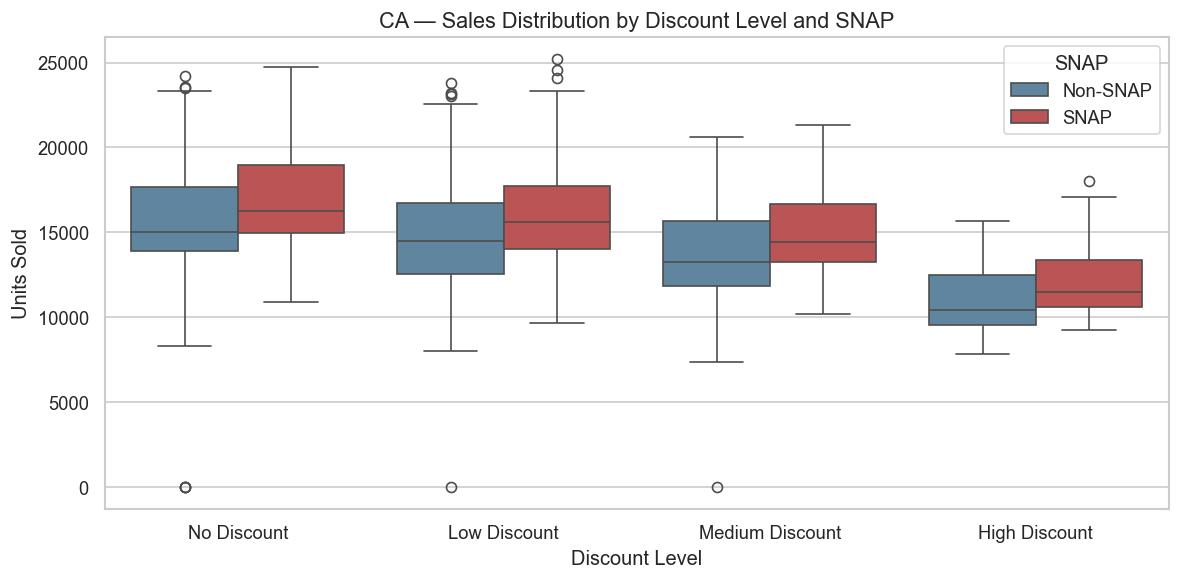

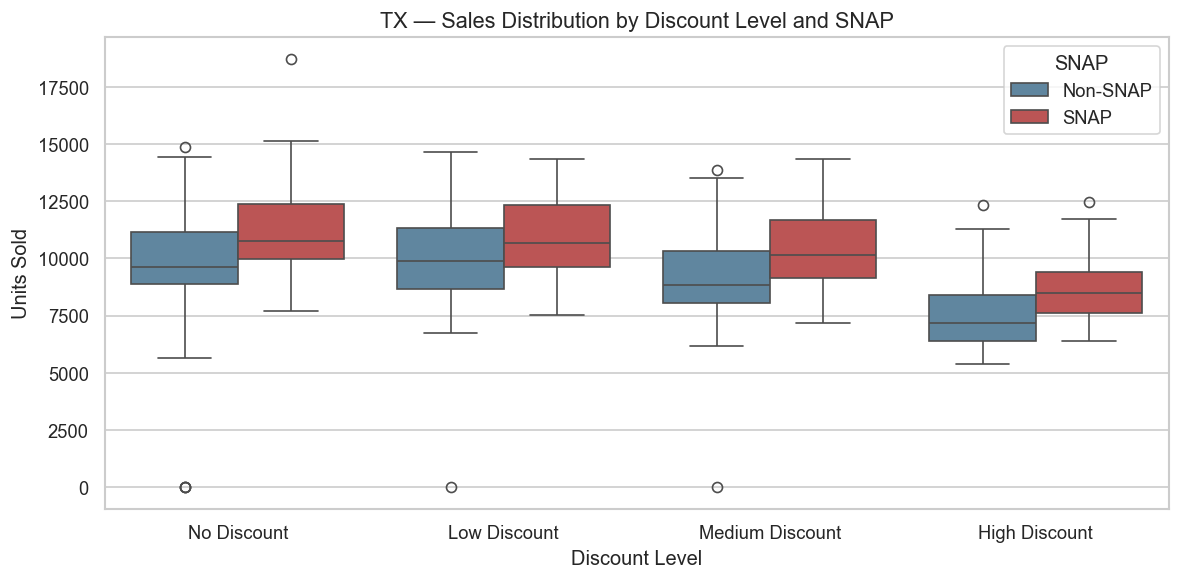

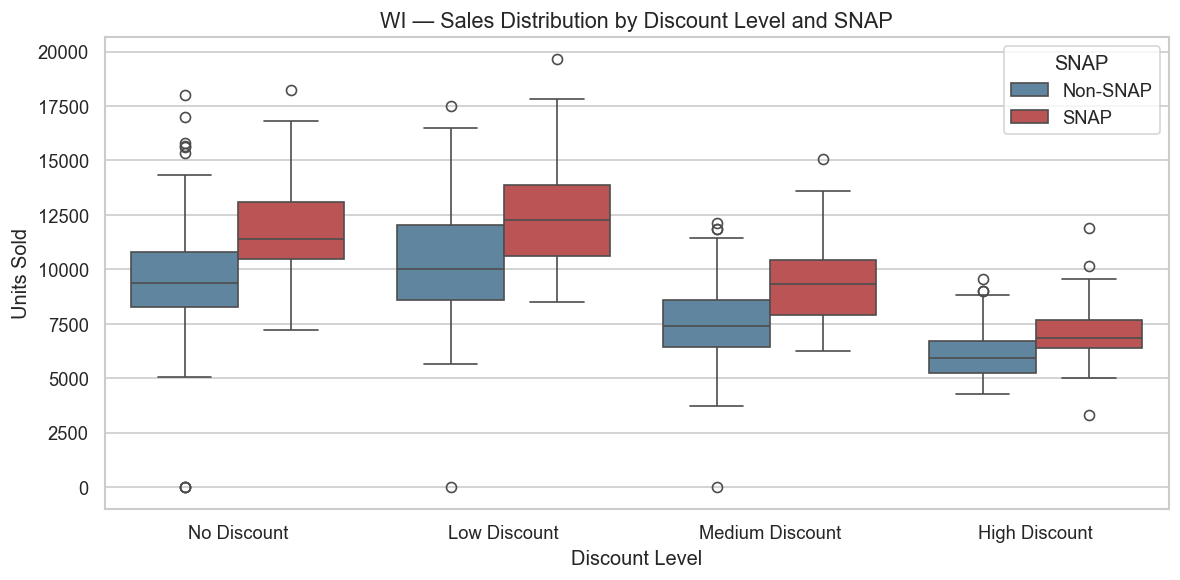

In [18]:
# ── SNAP × Discount interaction: per-state boxplots ──────────────────────────
for state, snap_col in snap_map.items():
    fig, ax = plt.subplots(figsize=(10, 5))
    sub = state_daily_disc[state_daily_disc["state_id"] == state].copy()
    sub["SNAP"] = sub[snap_col].map({0: "Non-SNAP", 1: "SNAP"})

    sns.boxplot(
        data=sub,
        x="discount_level",
        y="units",
        hue="SNAP",
        hue_order=["Non-SNAP", "SNAP"],
        palette={"Non-SNAP": "#5588aa", "SNAP": "#cc4444"},
        ax=ax
    )
    ax.set_title(f"{state} — Sales Distribution by Discount Level and SNAP", fontsize=13)
    ax.set_xlabel("Discount Level")
    ax.set_ylabel("Units Sold")
    plt.tight_layout()
    plt.show()

### Interpretation

SNAP timing consistently increases demand across all discount levels within each state. The lift pattern varies by state — WI shows the largest SNAP effect regardless of discount level, consistent with its higher overall SNAP lift (+21.8%).

The interaction between discounts and SNAP is modest: SNAP lift percentages are relatively stable across discount tiers within each state, suggesting that these two demand drivers operate **largely independently** rather than reinforcing each other. This means they can be modeled as separate features without a strong need for interaction terms.

---
## 7. Calendar Event Effects

The M5 calendar includes 162 event days across four types: Religious, National, Cultural, and Sporting. We examine whether events produce a consistent sales lift or whether the aggregate effect is more nuanced.

In [19]:
# ── Event type breakdown ──────────────────────────────────────────────────────
daily_totals["has_event"] = daily_totals["event_name_1"].notna()

avg_by_event = daily_totals.groupby("has_event")["total_sales"].mean()
lift = (avg_by_event[True] / avg_by_event[False] - 1) * 100

print(f"Avg sales on NORMAL days : {avg_by_event[False]:,.0f} units")
print(f"Avg sales on EVENT days  : {avg_by_event[True]:,.0f} units")
print(f"Sales lift on event days : {lift:+.1f}%")

# Break down by event type
event_lift = (
    daily_totals[daily_totals["has_event"]]
    .groupby("event_type_1")["total_sales"]
    .mean()
    .sort_values(ascending=False)
)
baseline = avg_by_event[False]

print("\nAvg sales lift by event type vs. normal days:")
for etype, val in event_lift.items():
    print(f"  {etype:15s}: {val:,.0f}  ({(val/baseline - 1)*100:+.1f}%)")

Avg sales on NORMAL days : 34,489 units
Avg sales on EVENT days  : 32,655 units
Sales lift on event days : -5.3%

Avg sales lift by event type vs. normal days:
  Sporting       : 35,796  (+3.8%)
  Cultural       : 34,235  (-0.7%)
  Religious      : 33,761  (-2.1%)
  National       : 29,459  (-14.6%)


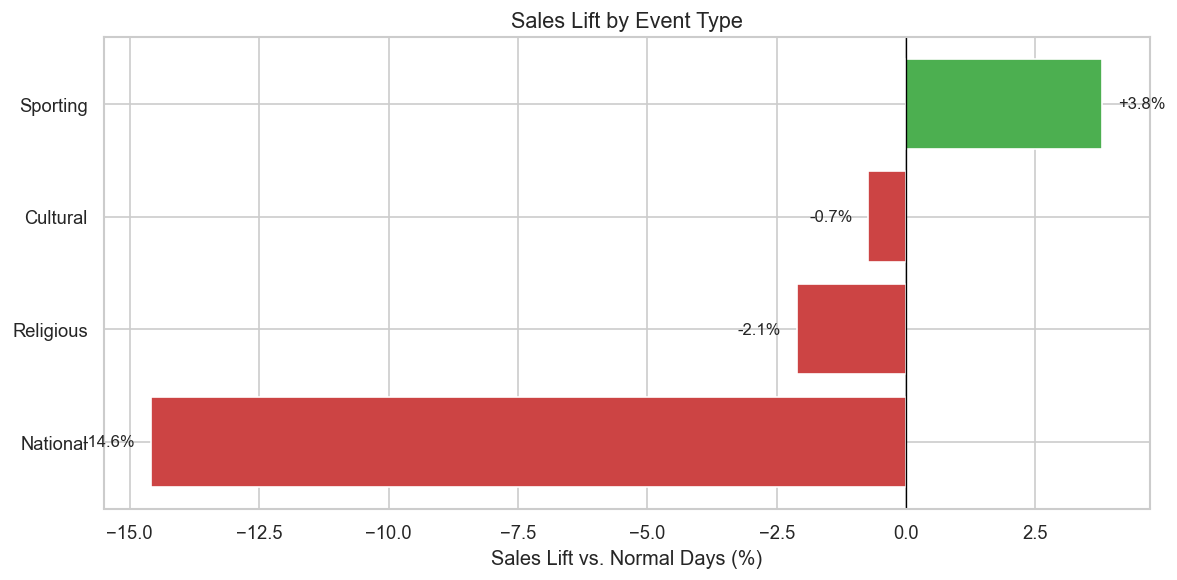

In [20]:
# ── Sales lift by event type ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

event_data = daily_totals[daily_totals["has_event"]].copy()
normal_avg = daily_totals[~daily_totals["has_event"]]["total_sales"].mean()

lift_by_type = (
    event_data.groupby("event_type_1")["total_sales"]
    .mean()
    .sort_values(ascending=True)
)
lift_pct = ((lift_by_type / normal_avg) - 1) * 100

colors = ["#cc4444" if v < 0 else "#4CAF50" for v in lift_pct]
bars = ax.barh(lift_pct.index, lift_pct.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Sales Lift vs. Normal Days (%)")
ax.set_title("Sales Lift by Event Type", fontsize=13)

for bar, val in zip(bars, lift_pct.values):
    ax.text(val + (0.3 if val >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f"{val:+.1f}%", va="center", ha="left" if val >= 0 else "right", fontsize=10)

plt.tight_layout()
plt.show()

### Interpretation

The aggregate event day lift is **-5.3%** — event days show *lower* total sales than normal days. This is driven by **National holidays** (-14.6%), when many Walmart stores operate on reduced hours or close entirely (e.g., Thanksgiving, Christmas). Sporting events (+3.8%) are the only type with a positive lift at the aggregate level.

This does not mean events are irrelevant for forecasting. The aggregate view masks **pre-event shopping behavior** — consumers stock up *before* holidays, and the sales impact is concentrated in specific categories. A binary event flag alone is insufficient; the *timing* relative to events matters more than whether an event is happening that day.

---
## Next Steps: External Data Enrichment

The M5 dataset provides sales, prices, calendar events, and SNAP flags — but this EDA reveals gaps that the internal data alone cannot address:

- **SNAP issuance:** The binary on/off flags don't capture *when* within the month benefits are issued per state, or how the demand effect fades over time. We need the actual issuance schedules.

- **Weather:** The dataset contains no weather information, yet retail foot traffic is clearly affected by storms, extreme temperatures, and seasonal weather patterns — particularly across states as different as California and Wisconsin.

- **Macroeconomic conditions:** Consumer spending power shifts with gas prices, unemployment, and inflation. These external economic forces affect demand independently of anything in the M5 data.

- **School calendars:** Back-to-school periods are a known driver of retail demand, especially for categories like HOUSEHOLD and HOBBIES. The M5 calendar does not include school schedules.

The following notebooks (01a–01e) scrape and process each of these external sources into feature CSVs for use in downstream modeling.

---
## Conclusion

This EDA established three findings that shape the rest of the pipeline:

1. **Item-level sparsity is severe** (~68% zero-sales cells), making item-level forecasting noisy. NB02 aggregates to category-store to recover signal.
2. **Aggregate event-day sales are *lower* than baseline** (-5.3%) because store closures dominate the day itself; the real demand signal is in the *pre-event ramp*. This motivates the proximity-based event features in NB01b rather than binary event flags.
3. **SNAP issuance dynamics are state-specific**, with each state operating on its own monthly schedule. NB01a builds per-state SNAP proximity features rather than a single national flag.

The discount correlation observed here is confounded by seasonality — items are discounted more during slow periods — so it cannot be interpreted as causal price elasticity. Causal price effects are addressed in NB02 via lag features.

**Next**: NB01a–01e build the external feature tables; NB02 merges everything into a model-ready dataset.